Congrats! You just graduated UVA's BSDS program and got a job working at a movie studio in Hollywood. 

Your boss is the head of the studio and wants to know if they can gain a competitive advantage by predicting new movies that might get high imdb scores (movie rating). 

You would like to be able to explain the model to mere mortals but need a fairly robust and flexible approach so you've chosen to use decision trees to get started. 

In doing so, similar to  great data scientists of the past you remembered the excellent education provided to you at UVA in a undergrad data science course and have outline 20ish steps that will need to be undertaken to complete this task. As always, you will need to make sure to #comment your work heavily. 

 Footnotes: 
-	You can add or combine steps if needed
-	Also, remember to try several methods during evaluation and always be mindful of how the model will be used in practice.
- Make sure all your variables are the correct type (factor, character,numeric, etc.)

In [1]:
import pandas as pd
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import graphviz
from sklearn.model_selection import train_test_split,GridSearchCV,RepeatedStratifiedKFold
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import plot_tree, DecisionTreeClassifier, export_graphviz

In [2]:
#1. Load the data
#Sometimes need to set the working directory back out of a folder that we create a file in

#import os
#os.listdir()
#print(os.getcwd())
#os.chdir('c:\\Users\\Brian Wright\\Documents\\3001Python\\DS-3001')

movie_metadata=pd.read_csv("../data/movie_metadata.csv") # Reading the data

movie_metadata.head() # Printing the first five lines of the dataset

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,131.0,NaN,Documentary,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0


2 Ensure all the variables are classified correctly including the target variable and collapse factor variables as needed.

All answers from question 2 are part of the function in question 3.

3 Check for missing variables and correct as needed. Once you've completed the cleaning again create a function that will do this for you in the future. In the submission, include only the function and the function call.

In [3]:
# Creating a function to clean the dataset

def clean_data(df):
    df = df.dropna()
    df1 = df.drop(columns = ['director_name', 'director_facebook_likes', 'actor_3_facebook_likes', 'actor_2_name', 'actor_1_facebook_likes', 'gross', 'actor_1_name', 'movie_title', 'actor_3_name', 'plot_keywords', 'movie_imdb_link', 'actor_2_facebook_likes', 'aspect_ratio', 'genres', 'language', 'country', 'content_rating'])
    movies_data = pd.get_dummies(df1, columns = ['color'], drop_first = True)
    movies_data['imdb_score'] = (movies_data['imdb_score'] >= 7.0).astype(int)

    return movies_data

movies_data = clean_data(movie_metadata) # Calling the function

movies_data.head() # Ensuring the function worked
    

,num_critic_for_reviews,duration,num_voted_users,cast_total_facebook_likes,facenumber_in_poster,num_user_for_reviews,budget,title_year,imdb_score,movie_facebook_likes,color_Color
0,723.0,178.0,886204,4834,0.0,3054.0,237000000.0,2009.0,1,33000,True
1,302.0,169.0,471220,48350,0.0,1238.0,300000000.0,2007.0,1,0,True
2,602.0,148.0,275868,11700,1.0,994.0,245000000.0,2015.0,0,85000,True
3,813.0,164.0,1144337,106759,0.0,2701.0,250000000.0,2012.0,1,164000,True
5,462.0,132.0,212204,1873,1.0,738.0,263700000.0,2012.0,0,24000,True


4 Guess what, you don't need to scale the data, because DTs don't require this to be done, they make local greedy decisions...keeps getting easier, go to the next step.

5 Determine the baserate or prevalence for the classifier, what does this number mean?

In [4]:
# calculating prevalence

print(movies_data['imdb_score'].value_counts())

1285/(2470+1285)

imdb_score
0    2470
1    1285
Name: count, dtype: int64


0.3422103861517976

This means that approximately 34.2% of the movies in the dataset have a higher rating than 7.

6 Split your data into test, tune, and train. (80/10/10)

In [5]:
X = movies_data.drop(columns = ['imdb_score']) # Dropping target variable
y = movies_data['imdb_score'] # Target variable

# Partitioning the data

X_train, X_temp, y_train, y_temp = train_test_split(X, y, train_size = 0.8, stratify = y, random_state = 42)
X_tune, X_test, y_tune, y_test = train_test_split(X_temp, y_temp, train_size = 0.5, stratify = y_temp, random_state = 42)


7 Create the kfold object for cross validation.

In [6]:
# Creating the kfold object

kf = RepeatedStratifiedKFold(n_splits = 10, n_repeats = 5, random_state = 42)

8 Create the scoring metric you will use to evaluate your model and the max depth hyperparameter (grid search) 

In [7]:
# Creating the scoring metric and max depth hyperparameter

scoring = ['roc_auc','recall','balanced_accuracy']

param = {"max_depth" : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],}

9 Build the classifier object 

In [8]:
cl= DecisionTreeClassifier(random_state = 500)

10 Use the kfold object and the scoring metric to find the best hyperparameter value for max depth via the grid search method.

In [10]:
grid_search = GridSearchCV(cl, param, scoring = scoring, n_jobs = 1, cv = kf, refit = 'roc_auc')

11 Fit the model to the training data.

In [ ]:
# Fitting the model to the training data

movies_model = grid_search.fit(X_train, y_train)

12 What is the best depth value?

In [13]:
best_depth = movies_model.best_estimator_

print(best_depth)

DecisionTreeClassifier(max_depth=5, random_state=500)


The best depth value is 5.

13 Print out the model

In [19]:
print(movies_model) # The model

GridSearchCV(cv=RepeatedStratifiedKFold(n_repeats=5, n_splits=10, random_state=42),
             estimator=DecisionTreeClassifier(random_state=500), n_jobs=1,
             param_grid={'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                       13, 14, 15]},
             refit='roc_auc',
             scoring=['roc_auc', 'recall', 'balanced_accuracy'])


14 View the results, comment on how the model performed using the metrics you selected.

In [29]:
# Calculating mean and standard deviation for the scoring metrics

auc = movies_model.cv_results_['mean_test_roc_auc']
recall = movies_model.cv_results_['mean_test_recall']
bal_acc = movies_model.cv_results_['mean_test_balanced_accuracy']

SDauc = movies_model.cv_results_['std_test_roc_auc']
SDrecall = movies_model.cv_results_['std_test_recall']
SDbal_acc = movies_model.cv_results_['std_test_balanced_accuracy']

depth = np.unique(movies_model.cv_results_['param_max_depth']).data

# Creating a dataframe to displays the model results

movies_data_model = pd.DataFrame(list(zip(depth, auc, recall, bal_acc, SDauc, SDrecall, SDbal_acc)),
               columns =['depth','auc','recall','bal_acc','aucSD','recallSD','bal_accSD'])

print(movies_data_model)

    depth       auc    recall   bal_acc     aucSD  recallSD  bal_accSD
0       1  0.653734  0.378824  0.653734  0.021925  0.055389   0.021925
1       2  0.712242  0.378824  0.653734  0.028948  0.055389   0.021925
2       3  0.781892  0.458744  0.685852  0.025176  0.052584   0.026346
3       4  0.801122  0.545505  0.720232  0.027674  0.059236   0.026768
4       5  0.805348  0.567101  0.723326  0.027420  0.061346   0.029575
5       6  0.801916  0.560539  0.723853  0.026984  0.051829   0.026011
6       7  0.789477  0.572970  0.726212  0.026823  0.045913   0.023543
7       8  0.767834  0.583845  0.725071  0.028566  0.045718   0.021963
8       9  0.747550  0.591645  0.723962  0.032619  0.050904   0.025743
9      10  0.731805  0.598073  0.722575  0.032201  0.045578   0.023474
10     11  0.716855  0.604706  0.720220  0.031591  0.045693   0.024458
11     12  0.709411  0.613069  0.719483  0.033831  0.050566   0.026634
12     13  0.707408  0.615966  0.716586  0.032588  0.047838   0.026114
13    

The model achieved its greatest mean area under the curve (auc) at a depth of 5, with an auc of approximately 0.805. The model correctly predicted roughly 62% of movies above a 7.0 rating, as shown by the recall of 0.62 at a depth of 15. The model was most accurate at a depth of 6, as shown by the greatest balanced accuracy value of approximately 0.726. There was little variance in the model's performance across different depth, as the standard deviation of auc, recall, and balanced accuracy did not change significantly from a depth of 1 to a depth of 15.

15 Which variables appear to be contributing the most (variable importance) 

In [30]:
# Calculating variable importance

variable_imp = pd.DataFrame(best_depth.feature_importances_, index=X_train.columns, columns=['importance']).sort_values('importance', ascending=False)

print(variable_imp)

                           importance
num_voted_users              0.556478
budget                       0.239471
duration                     0.105689
cast_total_facebook_likes    0.043868
num_user_for_reviews         0.023944
num_critic_for_reviews       0.019839
movie_facebook_likes         0.010711
facenumber_in_poster         0.000000
title_year                   0.000000
color_Color                  0.000000


The variable that is contributing the most is the number of voted users. Then, the budget of the movie is the second most import variable, with duration being the third most important variable. The other variables are significantly less important than these three variables.

16 Use the predict method on the tune data and print out the results.

In [38]:
pred_prob = movies_model.predict_proba(X_tune)[:,1] # Predicting the probabilities that the movie is rated higher than 7.0

print(pred_prob) # Printing the results

[0.58730159 0.22485207 0.2607362  0.22485207 0.51648352 0.58730159
 0.51648352 0.07939698 0.07939698 0.11428571 0.07939698 0.81818182
 0.11428571 0.76973684 0.07939698 0.2607362  0.22485207 0.07939698
 0.81818182 0.94680851 0.81818182 0.17410714 0.07939698 0.22485207
 0.07939698 0.17410714 0.22485207 0.17410714 0.17410714 0.2607362
 0.58730159 0.07939698 0.07939698 0.2607362  0.7755102  0.07939698
 0.07939698 0.54545455 0.07939698 0.07939698 0.07939698 0.17410714
 0.46666667 0.07939698 0.7755102  0.07939698 0.58730159 0.22485207
 0.17410714 0.07939698 0.07939698 0.11428571 0.38053097 0.07939698
 0.2607362  1.         0.26666667 0.11428571 0.07939698 0.07939698
 0.07939698 0.07939698 0.18367347 0.07939698 0.51648352 0.46666667
 0.51648352 0.07939698 0.07939698 0.18367347 0.07939698 0.54545455
 0.11428571 0.97826087 0.07939698 0.7755102  0.07939698 0.81818182
 0.07939698 0.17410714 0.58730159 0.18367347 0.2607362  0.94680851
 0.7        0.07939698 0.46666667 0.51648352 0.94680851 0.22485

17 How does the model perform on the tune data?

The model performs fairly well on the tune data, as there are many movies with a high probability (near 1.0) of having a rating higher than 7.0. It also correctly predicts many low-rated movies, as shown by the lower probabilities (near 0.0) in the output above. 

18 Print out the confusion matrix for the tune data, what does it tell you about the model?

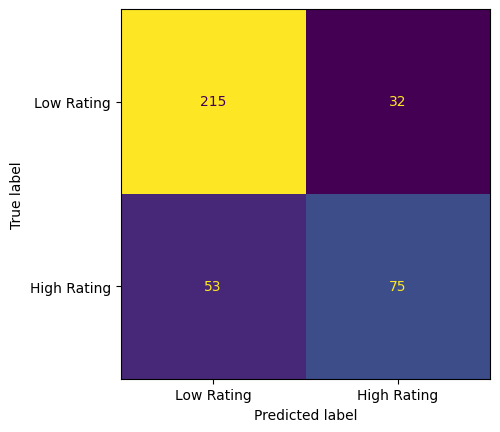

In [41]:
# Creating the confusion matrix

print(ConfusionMatrixDisplay.from_estimator(best_depth, X_tune, y_tune, display_labels = ['Low Rating','High Rating'], colorbar=False))

The model did a good job of predicting the movies with a lower rating than 7.0, as shown by the number of true negative values (215). It also correctly predicted 75 true positives, the movies with an actual higher than 7.0 rating. However, the model incorrectly predicted 53 movies as lower than 7.0 when they were higher (false negative) and 32 movies as higher than 7.0 when they were lower (false positive).

19 What are the top 3 movies based on the tune set? Which variables are most important in predicting the top 3 movies?

In [58]:
# Creating a dataframe with the predicted probabilities

predictions = pd.DataFrame(pred_prob, index = X_tune.index, columns=['predicted_prob'])

# Printing the three highest predicted probabilities

print(predictions.sort_values(by = 'predicted_prob', ascending = False).head(3))

# Indexing from the original dataset to get the names of these movies

print(movie_metadata.iloc[[3355, 4557, 439]]['movie_title'])

# Calculating variable importance

variable_imp = pd.DataFrame(best_depth.feature_importances_, index=X_tune.columns, columns=['importance']).sort_values('importance', ascending=False)

print(variable_imp)


      predicted_prob
3355             1.0
4557             1.0
439              1.0
3355        Pulp Fiction 
4557                Juno 
439     The Hunger Games 
Name: movie_title, dtype: object
                           importance
num_voted_users              0.556478
budget                       0.239471
duration                     0.105689
cast_total_facebook_likes    0.043868
num_user_for_reviews         0.023944
num_critic_for_reviews       0.019839
movie_facebook_likes         0.010711
facenumber_in_poster         0.000000
title_year                   0.000000
color_Color                  0.000000


The top 3 movies based on the tune set are Pulp Fiction, Juno, and The Hunger Games. Similarly to the train set, the most important variables were the number of voted users, the budget, and the duration of the movie.

20 Use a different hyperparameter for the grid search function and go through the process above again using the tune set. 

      predicted_prob
3355             1.0
4795             1.0
2829             1.0
3355                       Pulp Fiction 
4795    Monty Python and the Holy Grail 
2829                           Downfall 
Name: movie_title, dtype: object
                           importance
num_voted_users              0.502492
budget                       0.220971
duration                     0.111858
cast_total_facebook_likes    0.051489
num_user_for_reviews         0.033472
title_year                   0.030245
movie_facebook_likes         0.025184
num_critic_for_reviews       0.018217
facenumber_in_poster         0.006071
color_Color                  0.000000


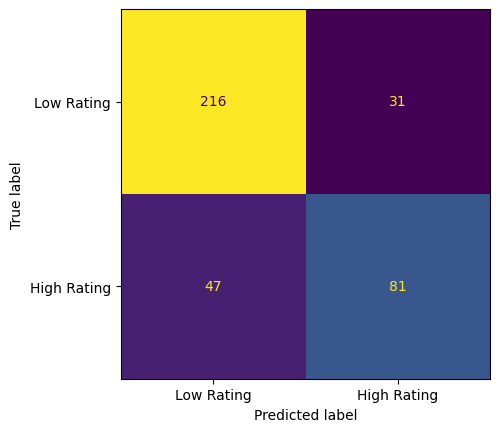

In [69]:
# Using min_samples_leaf as the new hyperparameter

param = {"min_samples_leaf" : [5, 10, 15, 20, 25],}

# Define a new grid search function with min_samples_leaf as the new hyperparameter

grid_search2 = GridSearchCV(cl, param, scoring = scoring, n_jobs = 1, cv = kf, refit = 'roc_auc')

# Fitting the model to the training data

movies_model2 = grid_search2.fit(X_train, y_train)

# Creating a confusion matrix to evaluate the tune set accuracy

print(ConfusionMatrixDisplay.from_estimator(movies_model2.best_estimator_, X_tune, y_tune, display_labels = ['Low Rating','High Rating'], colorbar=False))

# Analyzing the top 3 movies and variable importance with the new hyperparameter

# Creating a dataframe with the predicted probabilities

pred_prob2 = movies_model2.predict_proba(X_tune)[:,1] # Predicting the probabilities that the movie is rated higher than 7.0

predictions2 = pd.DataFrame(pred_prob2, index = X_tune.index, columns=['predicted_prob'])

# Printing the three highest predicted probabilities

print(predictions2.sort_values(by = 'predicted_prob', ascending = False).head(3))

# Indexing from the original dataset to get the names of these movies

print(movie_metadata.iloc[[3355, 4795, 2829]]['movie_title'])

# Calculating variable importance

variable_imp2 = pd.DataFrame(movies_model2.best_estimator_.feature_importances_, index=X_tune.columns, columns=['importance']).sort_values('importance', ascending=False)

print(variable_imp2)


21 Did the model improve with the new hyperparameter search?

The model slightly improved with min_samples_leaf as the hyperparameter, as the true negative value increased by 1, the true positive value increased by 6, the false negative value decreased by 6, and the false positive value decreased by 1. 

22 Using the better model, predict the test data and print out the results.

In [84]:
pred_test = movies_model2.best_estimator_.predict(X_test) # Predicting the test data

print(pred_test) # Printing test data results

# Calculating the confusion matrix

tn, fp, fn, tp = metrics.confusion_matrix(y_test,pred_test).ravel() 

true_negative_rate = tn/(tn+fp)
true_positive_rate = tp/(tp+fn)
false_negative_rate = fn/(tp+fn)
false_positive_rate = fp/(tn+fp)

# Printing true negative positive and false negative, positive rates

print("True Negative Rate:", true_negative_rate)
print("True Positive Rate:", true_positive_rate)
print("False Negative Rate:", false_negative_rate)
print("False Positive Rate:", false_negative_rate)


[0 0 1 0 0 1 1 0 0 0 1 1 0 0 0 1 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 0 0 0 0 0 0 0 0 0 1 0 1 0 1 1 1 0 0
 0 0 1 1 1 0 1 0 0 0 0 1 1 1 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 1 0
 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 1 1 0 0
 0 1 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 1 0 0 0 0 1 0
 0 0 0 0 0 1 0 1 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 1 0 0 1 1 1 0 0 1 0 0
 0 1 0 1 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0
 0 0 0 1 0 0 1 1 0 1 0 0 0 0 0 1 0 1 0 1 0 0 1 0 1 1 0 0 0 0 1 1 0 0 0 0 0
 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 1 1 1 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0
 0 0 0 0 1 0 0 0 0 1 1 1 0 1 1 1 0 1 1 0 1 0 1 0 1 0 0 0 1 0 0 0 1 1 0 1 0
 0 0 0 0 0 0]
True Negative Rate: 0.8704453441295547
True Positive Rate: 0.6046511627906976
False Negative Rate: 0.3953488372093023
False Positive Rate: 0.3953488372093023


23 Summarize what you learned along the way and make recommendations to your boss on how this could be used moving forward, being careful not to over promise.

As I worked through this lab, I learned that changing a hyperparameter can have an effect on the accuracy of a decision tree model. In both model's I used with different hyperparameters, the variables of most importance were the number of voted users, the duration, and the budget of the movie. Therefore, I would recommend to my boss that they place more importance on these variables when deciding on the production of a movie.